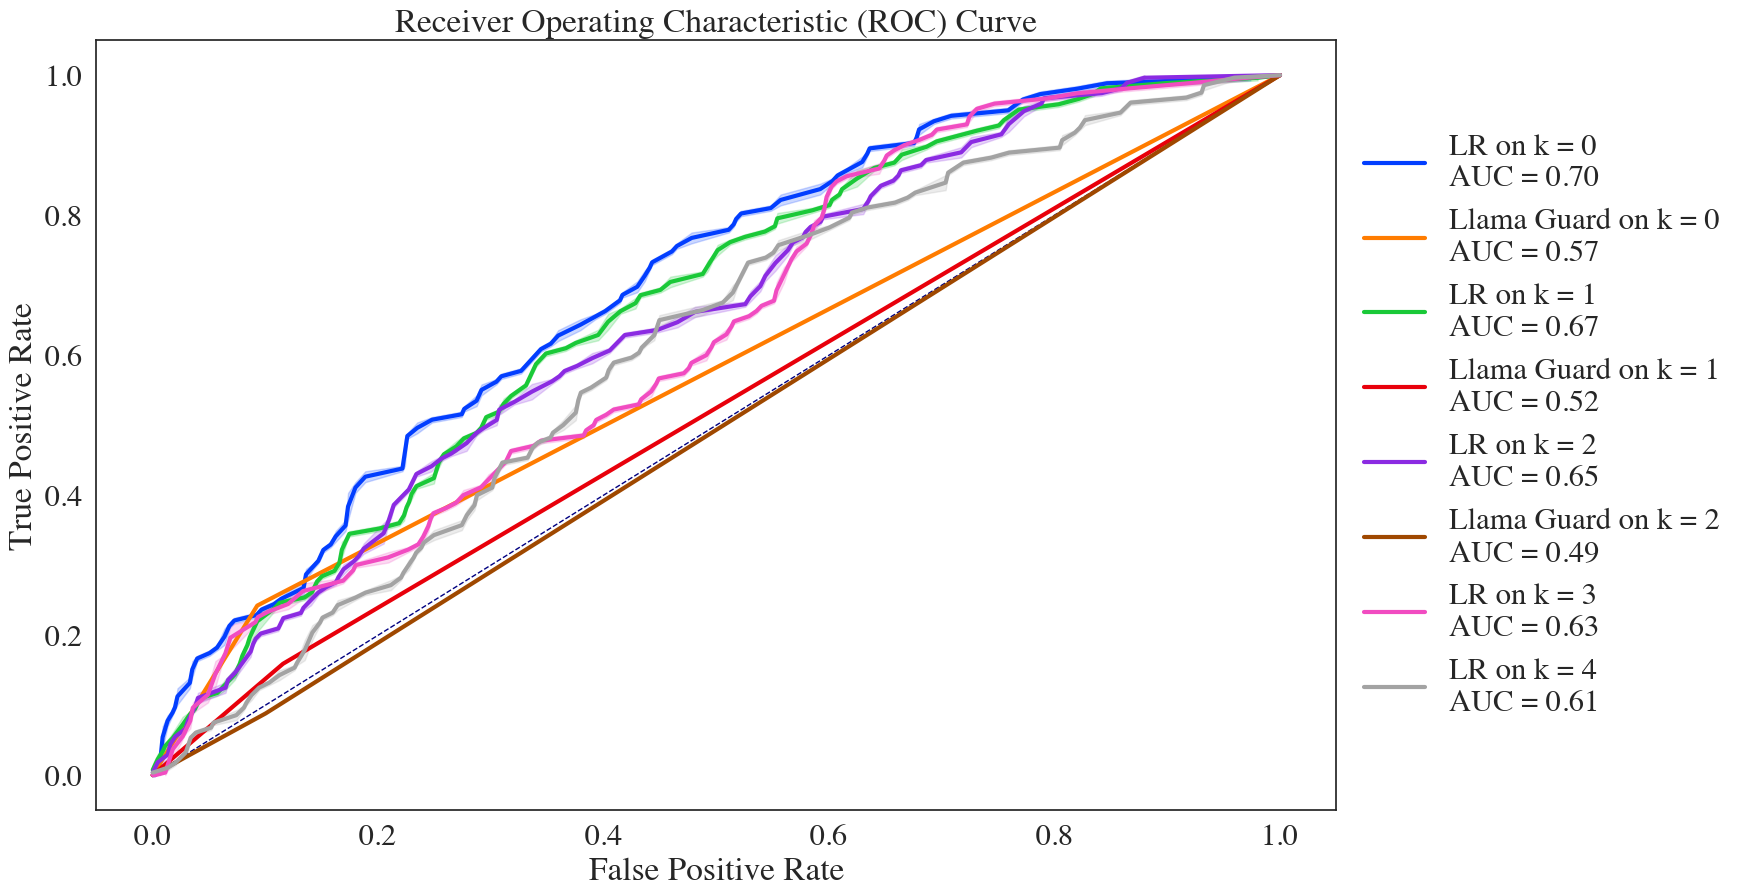

In [27]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


root_dir = Path("/Users/muberraozmen/Development/psycho-pass")
experiment_root = root_dir / "experiments" / "analysis"
results_dirs = {
    # (0, "GB"): experiment_root / "experiment3a" /"predictions_gradient_boosting.csv",
    (0, "LR"): experiment_root / "experiment3a" / "predictions_logistic_regression.csv",
    (0, "Llama Guard"): experiment_root / "experiment3a" / "predictions_llama_guard.csv",
    # (1, "GB"): experiment_root / "experiment3b" /"predictions_gradient_boosting.csv",
    (1, "LR"): experiment_root / "experiment3b" / "predictions_logistic_regression.csv",
    (1, "Llama Guard"): experiment_root / "experiment3b" / "predictions_llama_guard.csv",
    # (2, "GB"): experiment_root / "experiment3c" /"predictions_gradient_boosting.csv",
    (2, "LR"): experiment_root / "experiment3c" / "predictions_logistic_regression.csv",
    (2, "Llama Guard"): experiment_root / "experiment3c" / "predictions_llama_guard.csv",
    # (3, "GB"): experiment_root / "experiment3d" /"predictions_gradient_boosting.csv",
    (3, "LR"): experiment_root / "experiment3d" / "predictions_logistic_regression.csv",
    # (3, "Llama Guard"): experiment_root / "experiment3d" / "predictions_llama_guard.csv",
    # (4, "GB"): experiment_root / "experiment3e" /"predictions_gradient_boosting.csv",
    (4, "LR"): experiment_root / "experiment3e" / "predictions_logistic_regression.csv",
    # (4, "Llama Guard"): experiment_root / "experiment3e" / "predictions_llama_guard.csv",
}

plt.figure(figsize=(16, 10))
sns.set_theme(style="white", palette="bright", font='times', font_scale=2)

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')

for (trim, method), fname in results_dirs.items():
    predictions = pd.read_csv(fname)

    fpr, tpr, thresholds = roc_curve(predictions["outcome"], predictions["prediction"])
    roc_auc = auc(fpr, tpr)

    sns.lineplot(x=fpr, y=tpr, label=f'{method} on k = {trim} \nAUC = {roc_auc:.2f}', linewidth=3)

plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.savefig(root_dir/"paper"/"plots"/"exp3.pdf", bbox_inches='tight')
plt.show()

